# Feature Engineering v2

Este notebook transforma la `tabla_maestra2.csv` en el dataset final
listo para entrenar el modelo XGBoost.

La tabla maestra contiene los datos crudos integrados (Residencia + Nacionalidad).
Este notebook agrega las variables derivadas que el modelo necesita para aprender
patrones temporales, estacionales y demográficos.

### Variables que se crearán:

| Grupo | Variable | Descripción |
|---|---|---|
| Temporal | `mes_sin`, `mes_cos` | Codificación cíclica del mes (diciembre y enero son adyacentes) |
| Temporal | `Trimestre` | Agrupación trimestral (1–4) |
| Temporal | `Es_temporada_alta` | 1 si el mes es marzo, julio o diciembre |
| Temporal | `Años_desde_inicio` | Tendencia de crecimiento desde 2012 |
| Encoding | `Sexo_enc` | 0 = hombre, 1 = mujer |
| Encoding | `Region_enc` | Región geográfica como número |
| Encoding | `Aeropuerto_enc` | Aeropuerto como número (target encoding) |
| Encoding | `Pais_enc` | País como número (target encoding) |
| Rezago | `Lag_1_mes` | Turistas del mes anterior |
| Rezago | `Lag_2_mes` | Turistas de hace 2 meses |
| Rezago | `Lag_3_mes` | Turistas de hace 3 meses |
| Rezago | `Lag_12_meses` | Turistas del mismo mes del año anterior |
| Rezago | `Rolling_3m` | Promedio móvil de los últimos 3 meses |

**Producto final:** `dataset_para_modelo2.csv` con todas las features numéricas.

## 1. Carga de la tabla maestra v2

Se carga la tabla maestra generada en el notebook anterior.
Se verifica la dimensión, tipos de dato y ausencia de nulos
antes de comenzar cualquier transformación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 5)

URL = "https://raw.githubusercontent.com/Montiel-Oscar/ciencia_de_datos_2026_2/refs/heads/main/proyecto_borrador/datasets/tabla_maestra2.csv"

df = pd.read_csv(URL)
print(f"Cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nTipos de dato:")
print(df.dtypes)
print(f"\nNulos por columna:")
print(df.isnull().sum())
print(f"\nAños disponibles: {sorted(df['Año'].unique())}")
print(f"\nPrimeras 3 filas:")
print(df.head(3))

Cargado: 382,747 filas × 9 columnas

Tipos de dato:
Año                     int64
MesNum                  int64
Aeropuerto                str
Pais                      str
Región                    str
Sexo                      str
Valor_Residencia        int64
Valor_Nacionalidad    float64
nac_imputada            int64
dtype: object

Nulos por columna:
Año                   0
MesNum                0
Aeropuerto            0
Pais                  0
Región                0
Sexo                  0
Valor_Residencia      0
Valor_Nacionalidad    0
nac_imputada          0
dtype: int64

Años disponibles: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Primeras 3 filas:
    Año  MesNum      Aeropuerto       Pais   Región    Sexo  Valor_Residencia  \
0  2012       1  acapulco, gro.   alemania   europa  hombre                 1   
1  2012       1  acapu

## 2. Variables temporales

Se crean cuatro variables derivadas del tiempo:

- **`mes_sin` y `mes_cos`**: codificación cíclica mediante funciones seno y coseno.
  Esto permite que el modelo entienda que diciembre (12) y enero (1) son meses
  contiguos en el calendario, algo que un número entero no puede expresar.
  Es superior a usar solo `Trimestre` porque captura la continuidad del ciclo.

- **`Trimestre`**: agrupación en cuatro periodos de 3 meses.
  Útil para que el modelo aprenda patrones trimestrales.

- **`Es_temporada_alta`**: flag binario para los meses de mayor afluencia.
  Basado en el análisis exploratorio previo: marzo (Semana Santa + Spring Break),
  julio (verano) y diciembre (vacaciones navideñas) concentran los picos.

- **`Años_desde_inicio`**: captura la tendencia de crecimiento del turismo
  a lo largo del tiempo. El año 2012 = 0, el año 2025 = 13.

In [2]:
# Codificación cíclica del mes
df['mes_sin'] = np.sin(2 * np.pi * df['MesNum'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['MesNum'] / 12)

# Trimestre
df['Trimestre'] = ((df['MesNum'] - 1) // 3) + 1

# Temporada alta
df['Es_temporada_alta'] = df['MesNum'].isin([3, 7, 12]).astype(int)

# Tendencia de crecimiento
df['Años_desde_inicio'] = df['Año'] - 2012

print("Variables temporales creadas:")
print(df[['Año', 'MesNum', 'mes_sin', 'mes_cos', 'Trimestre',
          'Es_temporada_alta', 'Años_desde_inicio']].head(15))
print(f"\nDistribución temporada alta: {df['Es_temporada_alta'].value_counts().to_dict()}")
print(f"Distribución trimestre:      {df['Trimestre'].value_counts().sort_index().to_dict()}")

Variables temporales creadas:
     Año  MesNum  mes_sin   mes_cos  Trimestre  Es_temporada_alta  \
0   2012       1      0.5  0.866025          1                  0   
1   2012       1      0.5  0.866025          1                  0   
2   2012       1      0.5  0.866025          1                  0   
3   2012       1      0.5  0.866025          1                  0   
4   2012       1      0.5  0.866025          1                  0   
5   2012       1      0.5  0.866025          1                  0   
6   2012       1      0.5  0.866025          1                  0   
7   2012       1      0.5  0.866025          1                  0   
8   2012       1      0.5  0.866025          1                  0   
9   2012       1      0.5  0.866025          1                  0   
10  2012       1      0.5  0.866025          1                  0   
11  2012       1      0.5  0.866025          1                  0   
12  2012       1      0.5  0.866025          1                  0   
13  

## 3. Encoding de variables categóricas

El modelo XGBoost requiere que todas las variables sean numéricas.
Se aplican dos estrategias según la cardinalidad de cada columna:

**Label Encoding** (para columnas con pocos valores):
- `Sexo`: solo 2 valores → se convierte directamente (hombre=0, mujer=1).
- `Región`: 8 valores → se asigna un número entero a cada región.

**Target Encoding** (para columnas con muchos valores):
- `Aeropuerto`: 66 valores → se reemplaza por la media de `Valor_Residencia`
  de ese aeropuerto en el conjunto de entrenamiento.
- `Pais`: 243 valores → mismo procedimiento.

El target encoding se calcula **solo sobre el conjunto de entrenamiento**
(años ≤ 2023) para evitar fuga de información hacia el conjunto de prueba.
Los aeropuertos o países que aparezcan solo en test reciben la media global.

In [3]:
df['Sexo_enc'] = (df['Sexo'] == 'mujer').astype(int)
print("Sexo encoding:", df['Sexo_enc'].value_counts().to_dict())

le_region = LabelEncoder()
df['Region_enc'] = le_region.fit_transform(df['Región'])
print("\nRegión encoding:")
for i, clase in enumerate(le_region.classes_):
    print(f"  {i} → {clase}")

Sexo encoding: {0: 210619, 1: 172128}

Región encoding:
  0 → africa
  1 → america central
  2 → america del norte
  3 → america del sur
  4 → asia
  5 → europa
  6 → islas del caribe
  7 → oceania


In [4]:
df_train_enc = df[df['Año'] <= 2023].copy()
media_global = df_train_enc['Valor_Residencia'].mean()

media_aeropuerto = df_train_enc.groupby('Aeropuerto')['Valor_Residencia'].mean()
df['Aeropuerto_enc'] = df['Aeropuerto'].map(media_aeropuerto).fillna(media_global)

media_pais = df_train_enc.groupby('Pais')['Valor_Residencia'].mean()
df['Pais_enc'] = df['Pais'].map(media_pais).fillna(media_global)

print("Target encoding aplicado:")
print(df[['Aeropuerto', 'Aeropuerto_enc', 'Pais', 'Pais_enc']].head(10))
print(f"\nNulos en Aeropuerto_enc: {df['Aeropuerto_enc'].isnull().sum()}")
print(f"Nulos en Pais_enc:       {df['Pais_enc'].isnull().sum()}")
print(f"Media global (fallback): {media_global:.2f}")
print(f"Filas train (≤2023):     {len(df_train_enc):,}")
print(f"Filas test  (≥2024):     {len(df[df['Año']>=2024]):,}")

Target encoding aplicado:
       Aeropuerto  Aeropuerto_enc       Pais     Pais_enc
0  acapulco, gro.       54.190696   alemania   346.067821
1  acapulco, gro.       54.190696   alemania   346.067821
2  acapulco, gro.       54.190696  australia   106.638037
3  acapulco, gro.       54.190696  australia   106.638037
4  acapulco, gro.       54.190696   barbados     5.778982
5  acapulco, gro.       54.190696     brasil   576.738954
6  acapulco, gro.       54.190696     brasil   576.738954
7  acapulco, gro.       54.190696     canada  2128.982707
8  acapulco, gro.       54.190696     canada  2128.982707
9  acapulco, gro.       54.190696    ecuador   250.613761

Nulos en Aeropuerto_enc: 0
Nulos en Pais_enc:       0
Media global (fallback): 507.04
Filas train (≤2023):     310,446
Filas test  (≥2024):     72,301


## 4. Lag features (variables de rezago)

Las variables de rezago son las más importantes del modelo.
Capturan el historial reciente de cada combinación
`Aeropuerto + País + Sexo` y permiten al modelo aprender
tanto la tendencia de corto plazo como la estacionalidad anual.

**Orden crítico:** el dataframe debe estar ordenado por clave de serie
y luego por tiempo antes de calcular cualquier shift.
Un orden incorrecto produce lags con valores del aeropuerto equivocado.

**Variables creadas:**
- `Lag_1_mes`: turistas del mes anterior (mismo aeropuerto/país/sexo).
- `Lag_2_mes` y `Lag_3_mes`: tendencia de los 2 y 3 meses anteriores.
- `Lag_12_meses`: mismo mes del año anterior. Captura estacionalidad anual.
- `Rolling_3m`: promedio móvil de los 3 meses anteriores. Suaviza ruido.

**Tratamiento de nulos generados:**
Los primeros meses de cada serie no tienen historial y generan NaN.
- `Lag_12`, `Lag_2`, `Lag_3`: se imputan con `Rolling_3m` (mejor proxy disponible).
- `Lag_1` y `Rolling_3m`: no se pueden imputar con honestidad → se eliminan esas filas.

In [5]:
TARGET     = 'Valor_Residencia'
CLAVE_SERIE = ['Aeropuerto', 'Pais', 'Sexo']

# Ordenar por clave + tiempo (CRÍTICO)
df = df.sort_values(CLAVE_SERIE + ['Año', 'MesNum']).reset_index(drop=True)

# Calcular lags
df['Lag_1_mes']   = df.groupby(CLAVE_SERIE)[TARGET].shift(1)
df['Lag_2_mes']   = df.groupby(CLAVE_SERIE)[TARGET].shift(2)
df['Lag_3_mes']   = df.groupby(CLAVE_SERIE)[TARGET].shift(3)
df['Lag_12_meses'] = df.groupby(CLAVE_SERIE)[TARGET].shift(12)

df['Rolling_3m'] = (
    df.groupby(CLAVE_SERIE)[TARGET]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

print("Nulos por lag antes de imputar:")
lags_cols = ['Lag_1_mes', 'Lag_2_mes', 'Lag_3_mes', 'Lag_12_meses', 'Rolling_3m']
for col in lags_cols:
    n = df[col].isnull().sum()
    print(f"  {col:<15}: {n:,} ({n/len(df)*100:.1f}%)")

# Verificar lags con ejemplo de Cancún + EE.UU. + Mujer
print("\nVerificación temporal — Cancún · EE.UU. · Mujer:")
ejemplo = df[
    (df['Aeropuerto'] == 'cancun, q. roo') &
    (df['Pais'] == 'estados unidos') &
    (df['Sexo'] == 'mujer')
][['Año', 'MesNum', TARGET, 'Lag_1_mes', 'Lag_12_meses', 'Rolling_3m']].head(16)
print(ejemplo.to_string(index=False))

Nulos por lag antes de imputar:
  Lag_1_mes      : 11,736 (3.1%)
  Lag_2_mes      : 21,082 (5.5%)
  Lag_3_mes      : 29,337 (7.7%)
  Lag_12_meses   : 84,628 (22.1%)
  Rolling_3m     : 11,736 (3.1%)

Verificación temporal — Cancún · EE.UU. · Mujer:
 Año  MesNum  Valor_Residencia  Lag_1_mes  Lag_12_meses    Rolling_3m
2012       1            102143        NaN           NaN           NaN
2012       2            119101   102143.0           NaN 102143.000000
2012       3            146154   119101.0           NaN 110622.000000
2012       4            111853   146154.0           NaN 122466.000000
2012       5            108869   111853.0           NaN 125702.666667
2012       6            125052   108869.0           NaN 122292.000000
2012       7            118074   125052.0           NaN 115258.000000
2012       8             90690   118074.0           NaN 117331.666667
2012       9             57612    90690.0           NaN 111272.000000
2012      10             72645    57612.0           

In [6]:
# Imputar lags que sí pueden rellenarse con Rolling_3m
df['Lag_12_meses'] = df['Lag_12_meses'].fillna(df['Rolling_3m'])
df['Lag_2_mes']    = df['Lag_2_mes'].fillna(df['Rolling_3m'])
df['Lag_3_mes']    = df['Lag_3_mes'].fillna(df['Rolling_3m'])

# Eliminar filas donde Lag_1 o Rolling_3m son nulos (primer mes de cada serie)
filas_antes = len(df)
df = df.dropna(subset=['Lag_1_mes', 'Rolling_3m']).copy()
filas_despues = len(df)

print(f"Filas eliminadas: {filas_antes - filas_despues:,} ({(filas_antes-filas_despues)/filas_antes*100:.1f}%)")
print(f"Filas restantes:  {filas_despues:,}")
print(f"Nulos totales en lags: {df[lags_cols].isnull().sum().sum()}")
print(" Sin nulos en lag features")

Filas eliminadas: 11,736 (3.1%)
Filas restantes:  371,011
Nulos totales en lags: 0
 Sin nulos en lag features


## 5. Definición de features y reporte

Se define la lista exacta de variables que usará el modelo.

**Se excluye `Valor_Nacionalidad` de las features** aunque está en la tabla.
La razón: es un dato del mismo mes que se quiere predecir.
En producción, un hotel en febrero 2026 no sabría cuántos turistas
de cada nacionalidad llegaron ese mes hasta que el mes termine.
Incluirla sería fuga de información (*data leakage*).
`nac_imputada` sí se incluye porque es un flag de calidad del dato, no el dato en sí.

In [7]:
FEATURES = [
    # Temporales
    'MesNum', 'mes_sin', 'mes_cos', 'Trimestre',
    'Es_temporada_alta', 'Años_desde_inicio',
    # Demográficas (encoded)
    'Sexo_enc', 'Region_enc', 'Aeropuerto_enc', 'Pais_enc',
    # Calidad del dato
    'nac_imputada',
    # Rezagos
    'Lag_1_mes', 'Lag_2_mes', 'Lag_3_mes', 'Lag_12_meses', 'Rolling_3m'
]
TARGET = 'Valor_Residencia'

print(f"Features del modelo ({len(FEATURES)}):")
for f in FEATURES:
    nulos = df[f].isnull().sum()
    print(f"  {f:<20} nulos: {nulos}")

print(f"\nTarget: {TARGET}")
print(f"  Min:    {df[TARGET].min():,}")
print(f"  Max:    {df[TARGET].max():,}")
print(f"  Media:  {df[TARGET].mean():,.1f}")
print(f"  Mediana:{df[TARGET].median():,.0f}")

print(f"\nNota: media ({df[TARGET].mean():,.0f}) >> mediana ({df[TARGET].median():,.0f})")
print("El target está muy sesgado — se aplicará log1p al entrenar el modelo.")

Features del modelo (16):
  MesNum               nulos: 0
  mes_sin              nulos: 0
  mes_cos              nulos: 0
  Trimestre            nulos: 0
  Es_temporada_alta    nulos: 0
  Años_desde_inicio    nulos: 0
  Sexo_enc             nulos: 0
  Region_enc           nulos: 0
  Aeropuerto_enc       nulos: 0
  Pais_enc             nulos: 0
  nac_imputada         nulos: 0
  Lag_1_mes            nulos: 0
  Lag_2_mes            nulos: 0
  Lag_3_mes            nulos: 0
  Lag_12_meses         nulos: 0
  Rolling_3m           nulos: 0

Target: Valor_Residencia
  Min:    1
  Max:    332,671
  Media:  532.3
  Mediana:4

Nota: media (532) >> mediana (4)
El target está muy sesgado — se aplicará log1p al entrenar el modelo.


## 6. Split temporal y reporte final

En series de tiempo el split **nunca** es aleatorio.
El pasado siempre entrena y el futuro siempre evalúa.
Se usa 2012–2023 como entrenamiento y 2024–2025 como prueba.

Esto simula el escenario real: un hotel contrata el servicio en enero 2024
y el modelo debe predecir los meses siguientes usando solo historia pasada.

In [8]:
train = df[df['Año'] <= 2023]
test  = df[df['Año'] >= 2024]

print("=" * 55)
print("DATASET LISTO PARA MODELADO")
print("=" * 55)
print(f"Total filas:         {len(df):,}")
print(f"Features:            {len(FEATURES)}")
print(f"Train (2012–2023):   {len(train):,} filas")
print(f"Test  (2024–2025):   {len(test):,} filas")
print(f"Nulos en features:   {df[FEATURES].isnull().sum().sum()}")
print(f"Nulos en target:     {df[TARGET].isnull().sum()}")
print(f"Aeropuertos:         {df['Aeropuerto'].nunique()}")
print(f"Países:              {df['Pais'].nunique()}")
print(f"Años en train:       {sorted(train['Año'].unique())}")
print(f"Años en test:        {sorted(test['Año'].unique())}")

DATASET LISTO PARA MODELADO
Total filas:         371,011
Features:            16
Train (2012–2023):   299,797 filas
Test  (2024–2025):   71,214 filas
Nulos en features:   0
Nulos en target:     0
Aeropuertos:         66
Países:              243
Años en train:       [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023)]
Años en test:        [np.int64(2024), np.int64(2025)]


## 7. Visualización del target

Se visualiza la distribución del target antes y después de la transformación
logarítmica para confirmar que `log1p` normaliza correctamente la distribución.
Esta gráfica forma parte del análisis exploratorio del documento del proyecto.

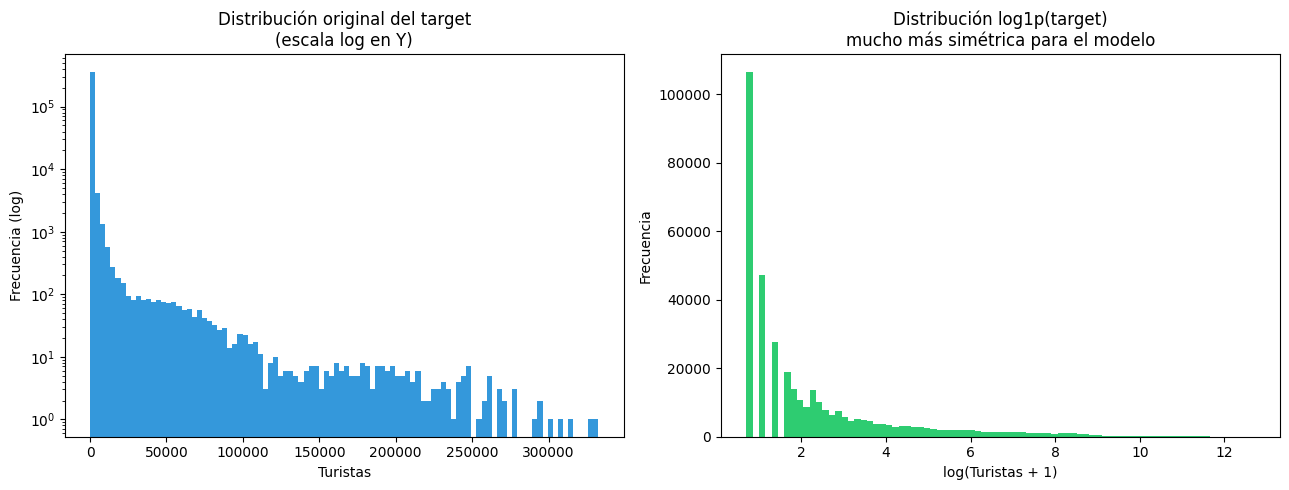

Original — media: 532.3  mediana: 4
log1p    — media: 2.292  mediana: 1.609


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df[TARGET], bins=100, color='#3498db', log=True, edgecolor='none')
axes[0].set_title('Distribución original del target\n(escala log en Y)')
axes[0].set_xlabel('Turistas')
axes[0].set_ylabel('Frecuencia (log)')

axes[1].hist(np.log1p(df[TARGET]), bins=80, color='#2ecc71', edgecolor='none')
axes[1].set_title('Distribución log1p(target)\nmucho más simétrica para el modelo')
axes[1].set_xlabel('log(Turistas + 1)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"Original — media: {df[TARGET].mean():,.1f}  mediana: {df[TARGET].median():,.0f}")
print(f"log1p    — media: {np.log1p(df[TARGET]).mean():.3f}  mediana: {np.log1p(df[TARGET]).median():.3f}")

## 8. Muestra y exportación

Se imprime una muestra de 3 filas del dataset final para confirmar
visualmente que las columnas tienen valores coherentes,
y se exporta `dataset_para_modelo2.csv` listo para el notebook de modelado.

In [10]:
print("Muestra de 3 filas del dataset final:")
cols_muestra = ['Año', 'MesNum', 'Aeropuerto', 'Pais', 'Sexo',
                TARGET, 'mes_sin', 'mes_cos', 'Aeropuerto_enc',
                'Pais_enc', 'Lag_1_mes', 'Lag_12_meses', 'Rolling_3m']
print(df[cols_muestra].head(3).to_string())

print(f"\nColumnas totales en el archivo a exportar: {df.shape[1]}")
print(f"Filas totales: {len(df):,}")
print(f"Nulos totales: {df.isnull().sum().sum()}")

Muestra de 3 filas del dataset final:
    Año  MesNum                                 Aeropuerto     Pais    Sexo  Valor_Residencia       mes_sin   mes_cos  Aeropuerto_enc  Pais_enc  Lag_1_mes  Lag_12_meses  Rolling_3m
2  2024       5  a.i tulum felipe carrillo puerto, q. roo.  albania  hombre                 1  5.000000e-01 -0.866025      507.044294  4.232919        1.0           1.0         1.0
3  2024       6  a.i tulum felipe carrillo puerto, q. roo.  albania  hombre                 1  1.224647e-16 -1.000000      507.044294  4.232919        1.0           1.0         1.0
4  2024       8  a.i tulum felipe carrillo puerto, q. roo.  albania  hombre                 4 -8.660254e-01 -0.500000      507.044294  4.232919        1.0           1.0         1.0

Columnas totales en el archivo a exportar: 23
Filas totales: 371,011
Nulos totales: 0


In [ ]:
df.to_csv('dataset_para_modelo2.csv', index=False)

from google.colab import files
files.download('dataset_para_modelo2.csv')

print("=" * 55)
print("DATASET EXPORTADO — dataset_para_modelo2.csv")
print("=" * 55)
print(f"Filas:    {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print(f"Nulos:    {df.isnull().sum().sum()}")
print(f"\nFeatures del modelo ({len(FEATURES)}):")
print(FEATURES)
print(f"\nTarget: {TARGET}")
